# mDLAG (dense time-domain engine)

> **Engine class: dense exact GP** in the time domain - `VEMARDEngine`, LBFGS on kernel hypers each M-step. ARD on $C$-columns soft-prunes redundant latents.


Fits `mbrila.MDLAG` with `engine="time"` - dense time-domain GP + ARD on the loading matrix. `K_init = 4` columns; truth has $K_\text{true} = 2$ across-latents, so ARD should soft-prune the two spurious columns (their per-region $\alpha$ grows much larger).

Scenario: 3 regions × 100 neurons (matches the mDLAG paper), $K_\text{true} = 2$, $K_\text{init} = 4$.

See `examples/demo_mdlag_time.py` for the CLI equivalent.

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch
from mbrila import MDLAG, LatentSpec, MOSEKernel, VEMARDEngine
from mbrila.core.latent_spec import ARDPriorConfig
from mbrila.synthetic.multiregion import MultiRegionScenario

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## Scenario

In [2]:
n_trials, T, n_regions = 50, 200, 3
y_dim_per_region = 100
k_true, k_init = 2, 4  # truth has 2 across-latents; model is built with 4 (ARD prunes spurious)
sigma_across = 0.05
delay_amplitude = 3.0
per_latent_sigma_ratio, per_latent_amp_ratio = 10.0, 3.0

scenario = MultiRegionScenario(  # noqa: F821
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=k_true,
    n_within=0,
    lag_across=2,
    lag_within=1,
    sigma_across=sigma_across,
    sigma_within=sigma_across,
    delay_shape="constant",
    delay_amplitude=delay_amplitude,
    per_latent_amplitudes=tuple(
        delay_amplitude * (1.0 / per_latent_amp_ratio ** (k / max(k_true - 1, 1))) for k in range(k_true)
    ),
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(k_true - 1, 1))) for k in range(k_true)
    ),
    per_latent_shapes=tuple(["constant"] * k_true),
    region_heterogeneity=1.0,
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

n_across, n_within = k_init, 0
data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}\n"
    f"K_true={k_true}, K_init={k_init} (ARD will soft-prune spurious columns)"
)

data.y shape = (50, 200, 300)
truth['delay'] shape = (200, 2, 2)
truth['observable'] shape = (50, 200, 6)
K_true=2, K_init=4 (ARD will soft-prune spurious columns)


## Build & fit model

`VEMARDEngine` runs variational EM with LBFGS on the GP hyperparameters in the M-step.

In [3]:
spec = LatentSpec(
    n_across=n_across,
    n_within=(0,) * n_regions,
    selection="ard",
    ard_prior=ARDPriorConfig(shape=1e-3, rate=1e-3),
)
engine = VEMARDEngine(
    max_lbfgs_iter=40,
    lbfgs_history=15,
    log_every=25,
)
init_gamma = 0.1  # neither matches truth latent σ
model = MDLAG(
    latent_spec=spec,
    y_dims=scenario.y_dims,
    T=scenario.T,
    kernel_factory_across=lambda: MOSEKernel(num_regions=n_regions, init_sigma=init_gamma),
    engine="time",
    engine_override=engine,

    device=device,
    dtype=torch.float64,
).to(device)

model.initialize_from_data(data)

result = model.fit(data, max_iter=150, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[vem_ard] iter 25/150  ELBO = 194949.654


[vem_ard] iter 50/150  ELBO = 199752.407


[vem_ard] iter 75/150  ELBO = 203257.730


[vem_ard] iter 100/150  ELBO = 204803.342


[vem_ard] iter 125/150  ELBO = 205417.645


[vem_ard] iter 150/150  ELBO = 205710.113
fit done: 150 iters, wall = 2678.8s


## Extract fitted quantities (ARD-aware)

Subset fitted columns to those ARD considers active, then permutation-match to truth. ARD-pruned spurious columns are dropped so the figures only compare matched (latent, truth) pairs.

In [4]:
fitted_delay = demo.extract_delay(model, scenario.T)
fitted_obs = demo.extract_observable(model, data)
fitted_y = demo.extract_y_recon(model, data)
alpha_mean = demo.extract_ard_alpha(model)

# ARD-aware subset: keep only the active columns matched to truth.
fitted_obs_aligned, fitted_delay_aligned, K_match, ard_info = nb.restrict_to_ard_active(
    truth["observable"], truth["delay"], fitted_obs, fitted_delay, alpha_mean,
    n_regions=n_regions, k_true=k_true, k_init=k_init, n_within=0,
)
# Permute truth side to match the active-column order returned above so
# subsequent plot helpers receive aligned truth/fit pairs.
truth_obs_matched = ard_info["truth_obs_subset"]
truth_delay_matched = ard_info["truth_delay_subset"]
delay_rmse = float(ard_info["rmse"])
print(f"ARD active columns: {list(ard_info['active_cols'])}  matched_truth: {list(ard_info['matched_truth'])}")
print(f"K_match = {K_match} (truth K_true = {k_true}, model K_init = {k_init})")
print(f"delay_rmse (ARD-aware, K_match cols) = {delay_rmse:.4f} bins")

ARD active columns: [np.int64(0), np.int64(1)]  matched_truth: [np.int64(0), np.int64(1)]
K_match = 2 (truth K_true = 2, model K_init = 4)
delay_rmse (ARD-aware, K_match cols) = 1.1966 bins


## Figure 1 - Convergence

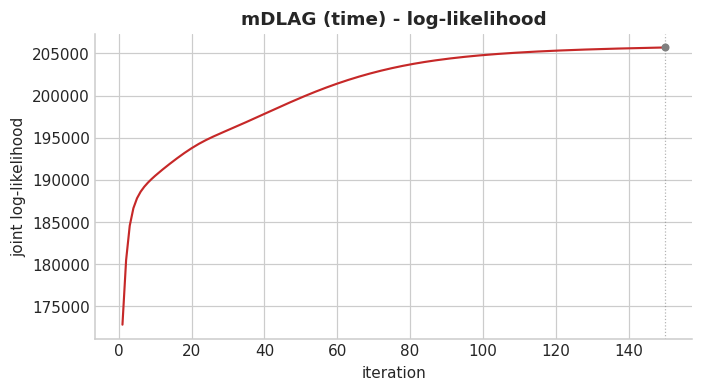

In [5]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="mDLAG (time) - log-likelihood")

## Figure 2 - Delay comparison (truth vs fit, per pair)

Only the ARD-active columns matched to truth are shown. Pruned columns are skipped.

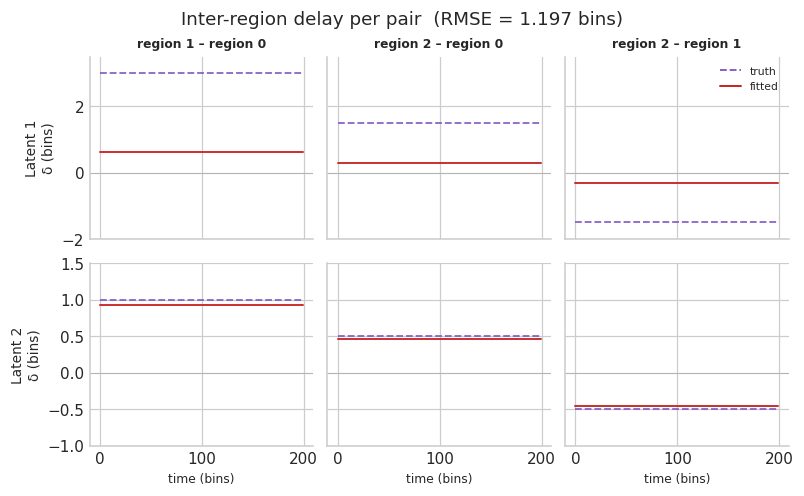

In [6]:
_ = nb.plot_delay_comparison(
    truth_delay_matched,
    fitted_delay_aligned,
    n_regions=n_regions,
    n_across=K_match,
    rmse=delay_rmse,
)

## Figure 3 - Per-latent traces (trial 0)

Same K_match active columns; truth dashed, fit solid (sign-aligned per panel).

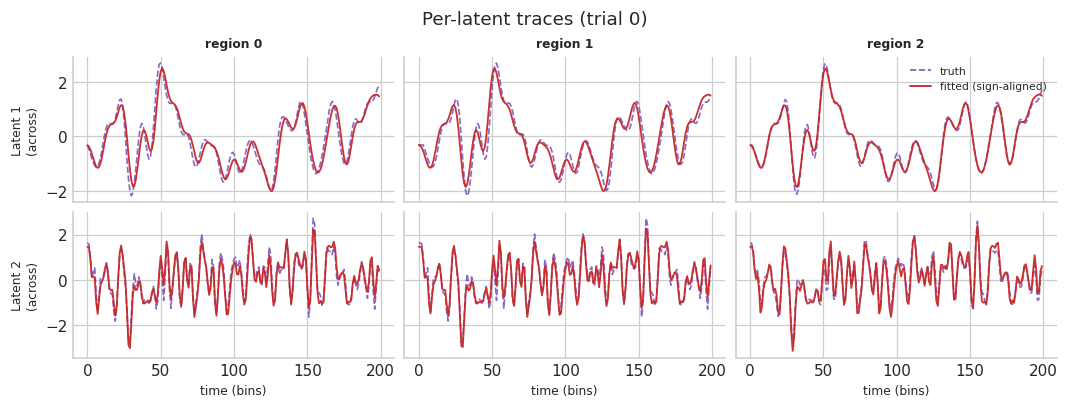

In [7]:
_ = nb.plot_latent_comparison(
    truth_obs_matched,
    fitted_obs_aligned,
    n_regions=n_regions,
    n_across=K_match,
    n_within=0,
    trial=0,
)

## Figure 4 - PSTH matrix comparison

Trial-averaged $y$ → neuron-by-time heatmap, region-grouped. Divergent `RdBu_r` colormap centred at 0.

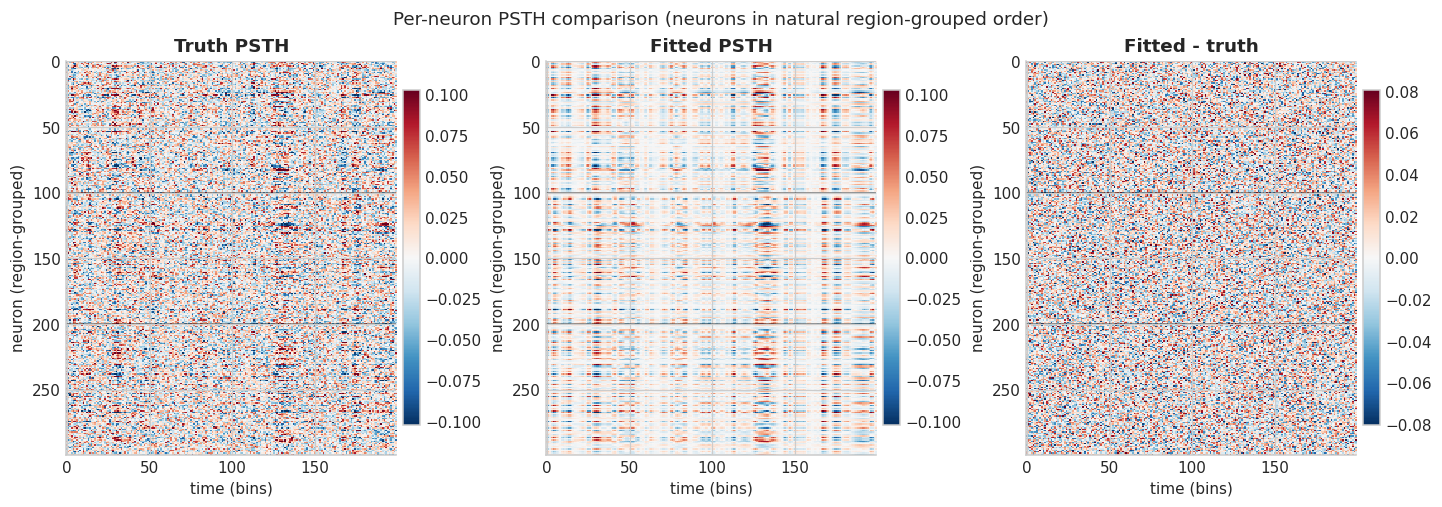

In [8]:
_ = nb.plot_psth_matrix(truth["y"], fitted_y, y_dims=scenario.y_dims)

## Figure 5 - Trial-0 reconstruction (top-variance neurons per region)

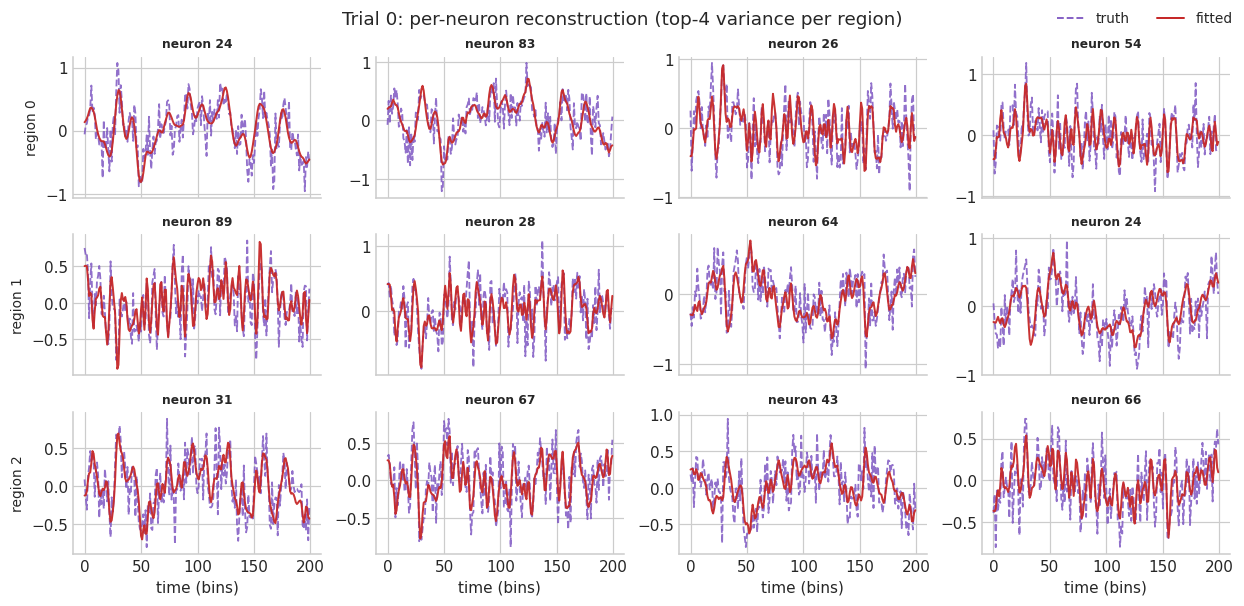

In [9]:
_ = nb.plot_trial0(truth["y"], fitted_y, y_dims=scenario.y_dims, trial=0, n_per_region=4)

## Figure 6 - ARD α per latent column

Max-over-region α per latent. Active latents (matched to truth) have small α; ARD-pruned spurious ones have α much larger.

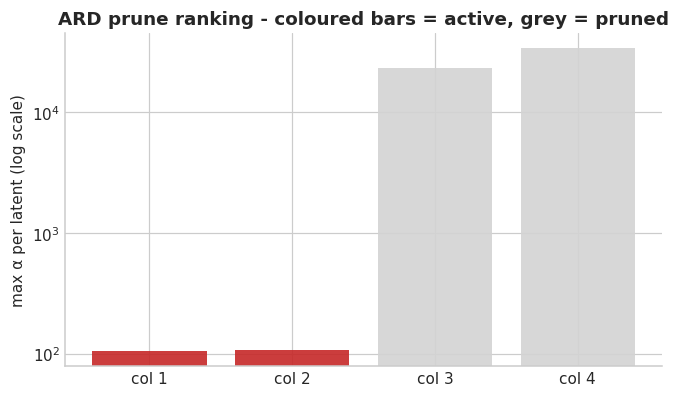

In [10]:
import matplotlib.pyplot as plt

max_per_col = alpha_mean.max(axis=0)
active = set(ard_info["active_cols"])
colors = [nb.FIT_COLOR if i in active else "lightgrey" for i in range(len(max_per_col))]

fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ax.bar(range(len(max_per_col)), max_per_col, color=colors, alpha=0.9)
ax.set_yscale("log")
ax.set_xticks(range(len(max_per_col)))
ax.set_xticklabels([f"col {i + 1}" for i in range(len(max_per_col))])
ax.set_ylabel("max α per latent (log scale)")
ax.set_title("ARD prune ranking - coloured bars = active, grey = pruned")
_ = fig

## Summary

In [11]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"delay_rmse (ARD-aware) = {delay_rmse:.4f} bins")
print(f"y_rmse (overall)       = {y_info['overall']:.4f}")
print(f"y_rmse per region      = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"K_match                = {K_match} of K_true = {k_true} (model K_init = {k_init})")
print(f"wall time              = {result.wall_time_s:.1f}s")

delay_rmse (ARD-aware) = 1.1966 bins
y_rmse (overall)       = 0.2230
y_rmse per region      = ['0.2229', '0.2228', '0.2233']
K_match                = 2 of K_true = 2 (model K_init = 4)
wall time              = 2678.8s
